# J10 — Transport de solutés et modélisation inverse

**Physique et hydrodynamique des sols** — S. J. Gumiere

*Atelier du Jour 10 : solutions analytiques de l'ADE, courbes de percée HYDRUS-1D, soluté réactif, estimation inverse de paramètres*

> Version **instructeur** : code complet et résultats.

## Mise en place

Colonne de référence (projets `J10_*`) : loam sableux, régime permanent $q = 10$ cm/j vers le bas, $\theta = 0{,}3293$,
$v = q/\theta = 30{,}4$ cm/j, $L = 60$ cm, pulse $c_0 = 1$ pendant $t_0 = 0{,}5$ j (masse injectée $q c_0 t_0 = 5$), $D_0 = 1$ cm²/j,
$\tau = \theta^{7/3}/\theta_s^2$ (Millington–Quirk), $D = \lambda v + D_0\tau$. Convention HYDRUS : flux positif vers le haut
(`cvBot` < 0 = sortie par le bas) ; dans les solutions analytiques, $x$ est la distance parcourue vers le bas.

In [1]:
import sys, time
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import special, optimize, linalg, integrate
from hydrus_io import read_solute, read_obs_node, read_nod_inf, read_tlevel

plt.rcParams.update({"figure.figsize": (7.5, 4), "axes.grid": True, "grid.alpha": 0.3})
HYD = "../../hydrus"
q, theta, theta_s = 10.0, 0.3293, 0.41
v = q / theta
tau = theta ** (7 / 3) / theta_s ** 2
De = 1.0 * tau
L, t0 = 60.0, 0.5
print(f"v = {v:.2f} cm/j ; tau = {tau:.3f} ; De = {De:.3f} cm²/j")

v = 30.37 cm/j ; tau = 0.445 ; De = 0.445 cm²/j


## Exercice 1 — Solutions analytiques de l'équation d'advection–dispersion  *(≈ 15 min)*

1. Implémenter `ade_step_flux(x, t, v, D, R=1, mu=0)` : concentration de flux $c_f/c_0$ pour une injection continue avec condition de flux
   à l'entrée (forme d'Ogata–Banks généralisée) : avec $v' = v/R$, $D' = D/R$, $u = v'\sqrt{1 + 4\mu D'/v'^2}$,
   $$\frac{c}{c_0} = \tfrac12 e^{(v'-u)x/2D'}\,\mathrm{erfc}\!\left(\frac{x - ut}{2\sqrt{D't}}\right) + \tfrac12 e^{(v'+u)x/2D'}\,\mathrm{erfc}\!\left(\frac{x + ut}{2\sqrt{D't}}\right).$$
   Implémenter aussi `ade_step_resident(x, t, v, D, R=1)` (concentration résidente, van Genuchten & Alves 1982, cas A2, sans dégradation) :
   $$\frac{c}{c_0} = \tfrac12\,\mathrm{erfc}\!\left(\frac{x - v't}{2\sqrt{D't}}\right) + \sqrt{\frac{v'^2 t}{\pi D'}}\,e^{-\frac{(x - v't)^2}{4D't}}
   - \tfrac12\left(1 + \frac{v'x}{D'} + \frac{v'^2 t}{D'}\right) e^{v'x/D'}\,\mathrm{erfc}\!\left(\frac{x + v't}{2\sqrt{D't}}\right).$$
2. Écrire `ade_pulse(x, t, v, D, t0, R=1, mu=0, kind="flux")` par superposition de deux échelons.
3. Pour $\lambda$ = 0,5, 2 et 10 cm : tracer les profils résidents $c(z)$ à $t$ = 0,25, 0,5, 1, 1,5, 2 j et les BTC (flux) à 60 cm ;
   vérifier la masse $\int_0^\infty q\,c_f\,dt = 5$ (`np.trapezoid`) et calculer $Pe = vL/D$ ; commenter la position et la hauteur du pic.
4. Vérifier que $c_f$ et $c_r$ diffèrent d'autant plus que $Pe$ est petit (écart maximal pour $\lambda$ = 0,5, 2, 10 cm).

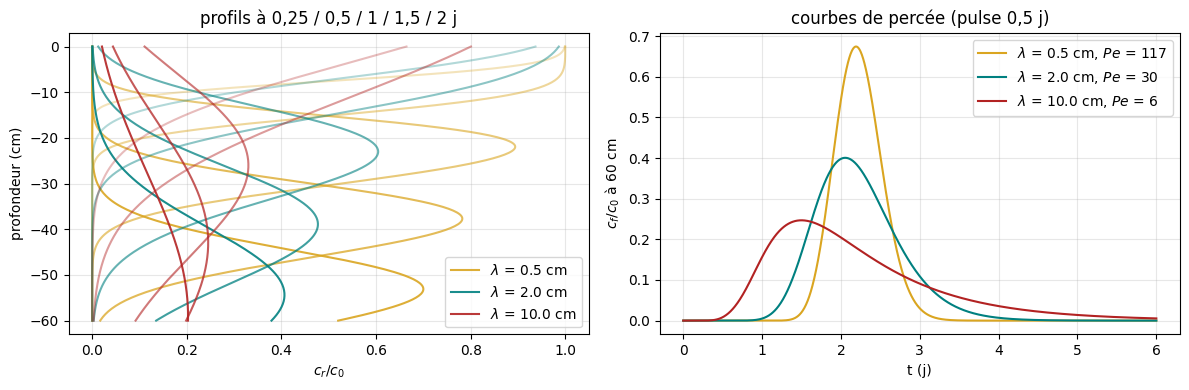

,lambda_cm,D_cm2_j,Pe,masse,t_pic,c_pic,t_moyen
0,0.5,15.629,116.580,5.000,2.190,0.674,2.226
1,2.0,61.180,29.782,5.000,2.054,0.401,2.226
2,10.0,304.120,5.991,4.941,1.498,0.247,2.167


lambda =  0.5 cm (Pe = 116.6) : écart max |c_f - c_r| à 60 cm = 0.0248
lambda =  2.0 cm (Pe =  29.8) : écart max |c_f - c_r| à 60 cm = 0.0379
lambda = 10.0 cm (Pe =   6.0) : écart max |c_f - c_r| à 60 cm = 0.0707


In [2]:
def ade_step_flux(x, t, v, D, R=1.0, mu=0.0):
    """Concentration de flux c/c0, injection continue, condition de flux à l'entrée (Ogata–Banks généralisée avec R et mu)."""
    t = np.asarray(t, float); x = np.asarray(x, float)
    vr, Dr = v / R, D / R
    u = vr * np.sqrt(1 + 4 * mu * Dr / vr ** 2)
    with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
        s = 2 * np.sqrt(np.maximum(Dr * t, 1e-300))
        c = 0.5 * np.exp((vr - u) * x / (2 * Dr)) * special.erfc((x - u * t) / s) \
            + 0.5 * np.exp((vr + u) * x / (2 * Dr)) * special.erfc((x + u * t) / s)
    return np.where(t > 0, np.nan_to_num(c), 0.0)

def ade_step_resident(x, t, v, D, R=1.0):
    """Concentration résidente c/c0, injection continue avec condition de flux (van Genuchten & Alves 1982, A2)."""
    t = np.asarray(t, float); x = np.asarray(x, float)
    vr, Dr = v / R, D / R
    with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
        s = 2 * np.sqrt(np.maximum(Dr * t, 1e-300))
        c = 0.5 * special.erfc((x - vr * t) / s) + np.sqrt(vr ** 2 * t / (np.pi * Dr)) * np.exp(-(x - vr * t) ** 2 / (4 * Dr * t)) \
            - 0.5 * (1 + vr * x / Dr + vr ** 2 * t / Dr) * np.exp(vr * x / Dr) * special.erfc((x + vr * t) / s)
    return np.where(t > 0, np.nan_to_num(c), 0.0)

def ade_pulse(x, t, v, D, t0, R=1.0, mu=0.0, kind="flux"):
    """Injection de durée t0 : différence de deux échelons (linéarité de l'ADE)."""
    f = ade_step_flux if kind == "flux" else (lambda x, t, v, D, R=1.0, mu=0.0: ade_step_resident(x, t, v, D, R))
    t = np.asarray(t, float)
    return f(x, t, v, D, R, mu) - f(x, np.maximum(t - t0, 0.0), v, D, R, mu)

# 3. profils et BTC
zz = np.linspace(0, 60, 300); tt = np.linspace(1e-3, 6, 1500)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
rows = []
for lam, col in zip([0.5, 2.0, 10.0], ["goldenrod", "teal", "firebrick"]):
    D = lam * v + De
    for k, t_ in enumerate([0.25, 0.5, 1.0, 1.5, 2.0]):
        ax[0].plot(ade_pulse(zz, t_, v, D, t0, kind="resident"), -zz, color=col, alpha=0.3 + 0.15 * k, label=f"$\\lambda$ = {lam} cm" if k == 4 else None)
    cf = ade_pulse(60, tt, v, D, t0)
    ax[1].plot(tt, cf, color=col, label=f"$\\lambda$ = {lam} cm, $Pe$ = {v*L/D:.0f}")
    rows.append(dict(lambda_cm=lam, D_cm2_j=D, Pe=v * L / D, masse=np.trapezoid(q * cf, tt), t_pic=tt[np.argmax(cf)], c_pic=cf.max(),
                     t_moyen=np.trapezoid(tt * cf, tt) / np.trapezoid(cf, tt)))
ax[0].set_xlabel("$c_r/c_0$"); ax[0].set_ylabel("profondeur (cm)"); ax[0].legend(); ax[0].set_title("profils à 0,25 / 0,5 / 1 / 1,5 / 2 j")
ax[1].set_xlabel("t (j)"); ax[1].set_ylabel("$c_f/c_0$ à 60 cm"); ax[1].legend(); ax[1].set_title("courbes de percée (pulse 0,5 j)")
plt.tight_layout(); plt.show()
display(pd.DataFrame(rows).round(3))

# 4. concentration de flux vs résidente
for lam in [0.5, 2.0, 10.0]:
    D = lam * v + De
    ecart = np.max(np.abs(ade_pulse(60, tt, v, D, t0) - ade_pulse(60, tt, v, D, t0, kind="resident")))
    print(f"lambda = {lam:4} cm (Pe = {v*L/D:5.1f}) : écart max |c_f - c_r| à 60 cm = {ecart:.4f}")

**Commentaire (instructeur).** La masse est conservée à $10^{-4}$ près pour les trois dispersivités ; le centre de masse arrive à $L/v + t_0/2 = 2{,}23$ j quelle que soit
$\lambda$, mais le pic est d'autant plus précoce et bas que $D$ est grand (2,19 → 2,05 → 1,50 j ; 0,67 → 0,40 → 0,25) : l'asymétrie de la BTC
en temps est une propriété de l'ADE, pas un artefact. L'écart maximal entre concentration de flux et résidente (Kreft & Zuber 1978) croît
de 0,025 à 0,07 (4 à 30 % du pic) quand $Pe$ passe de 117 à 6 : on doit savoir ce que mesure l'instrument (eau qui sort vs eau en place).

## Exercice 2 — Courbes de percée HYDRUS-1D et méthode des moments  *(≈ 15 min)*

Projets `J10_traceur_disp0.5cm`, `J10_traceur_disp2cm`, `J10_traceur_disp10cm` (mêmes conditions, $\lambda$ = 0,5 / 2 / 10 cm).

1. Lire `solute1.out` (`read_solute` : `cvBot`, `Sum(cvBot)`, `Sum(cvTop)`) et `OBS_NODE.OUT` (`read_obs_node`, variable `Conc`, nœuds 21, 41, 81, 121
   = 10, 20, 40, 60 cm). Tracer les BTC HYDRUS ($c_f = -$`cvBot`$/q$ à la sortie ; $c_r$ aux nœuds) avec les solutions analytiques correspondantes
   (flux à la sortie, résidente aux nœuds) ; RMSE par projet.
2. Bilan de masse : `Sum(cvTop)` (injectée) vs `Sum(cvBot)` à 6 j.
3. Moments temporels de $c_f(60, t)$ : $M_0 = q\int c_f\,dt$, $\bar t$, $\sigma_t^2$ ; en déduire $v = L/(\bar t - t_0/2)$ et
   $D = (\sigma_t^2 - t_0^2/12)\,v^3/(2L)$ ; comparer aux valeurs imposées ; expliquer l'écart pour $\lambda$ = 10 cm.
4. Profils `NOD_INF.OUT` (colonne `Conc(1..NS)`) à 0,5, 1, 1,5 j pour $\lambda$ = 2 cm vs solution résidente.

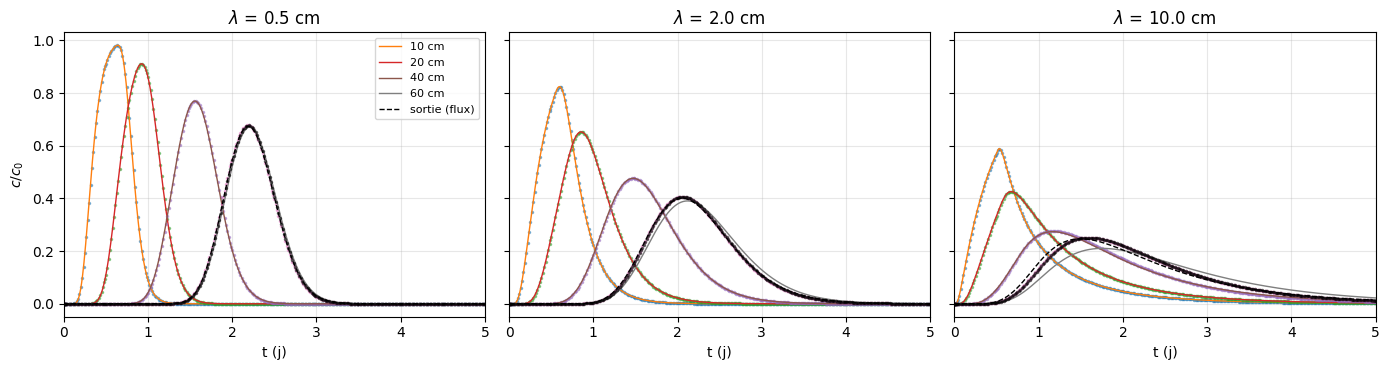

,lambda_cm,D,Pe,rmse_sortie,masse_injectee,masse_sortie
0,0.5,15.629,116.580,0.001,5.0,5.000
1,2.0,61.180,29.782,0.002,5.0,5.000
2,10.0,304.120,5.991,0.009,5.0,4.963


,lambda_cm,masse,t_moyen,variance,v_estime,v_impose,D_estime,D_impose
0,0.5,5.000,2.225,0.087,30.372,30.367,15.372,15.629
1,2.0,5.000,2.225,0.273,30.372,30.367,58.820,61.180
2,10.0,4.963,2.190,0.938,30.921,30.367,225.876,304.120


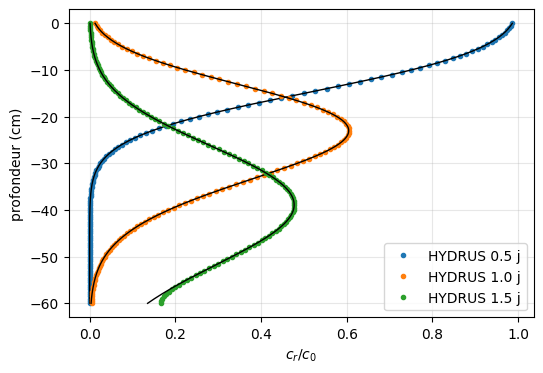

In [3]:
projets = {0.5: "J10_traceur_disp0.5cm", 2.0: "J10_traceur_disp2cm", 10.0: "J10_traceur_disp10cm"}
noeuds = {21: 10, 41: 20, 81: 40, 121: 60}
tt = np.linspace(1e-3, 6, 1500)

# 1-2. BTC et bilan de masse
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
rows = []
for a, (lam, nom) in zip(ax, projets.items()):
    so = read_solute(f"{HYD}/{nom}"); ob = read_obs_node(f"{HYD}/{nom}")
    D = lam * v + De
    for nd, z in noeuds.items():
        a.plot(ob.index, ob[(nd, "Conc")], ".", ms=3, alpha=0.5)
        a.plot(tt, ade_pulse(z, tt, v, D, t0, kind="resident"), lw=1, label=f"{z} cm")
    cf = -so["cvBot"] / q
    a.plot(so.index, cf, "k.", ms=3, alpha=0.5); a.plot(tt, ade_pulse(60, tt, v, D, t0), "k--", lw=1, label="sortie (flux)")
    a.set_title(f"$\\lambda$ = {lam} cm"); a.set_xlabel("t (j)"); a.set_xlim(0, 5)
    rmse = np.sqrt(np.mean((cf.to_numpy() - ade_pulse(60, so.index.to_numpy(), v, D, t0)) ** 2))
    rows.append(dict(lambda_cm=lam, D=D, Pe=v * L / D, rmse_sortie=rmse, masse_injectee=so["Sum(cvTop)"].iloc[-1], masse_sortie=-so["Sum(cvBot)"].iloc[-1]))
ax[0].set_ylabel("$c/c_0$"); ax[0].legend(fontsize=8); plt.tight_layout(); plt.show()
display(pd.DataFrame(rows).round(3))

# 3. moments
rows = []
for lam, nom in projets.items():
    so = read_solute(f"{HYD}/{nom}")
    cf = -so["cvBot"].to_numpy() / q; tim = so.index.to_numpy()
    M0 = np.trapezoid(cf, tim); t1 = np.trapezoid(tim * cf, tim) / M0; var = np.trapezoid((tim - t1) ** 2 * cf, tim) / M0
    v_est = L / (t1 - t0 / 2); D_est = (var - t0 ** 2 / 12) * v_est ** 3 / (2 * L)
    rows.append(dict(lambda_cm=lam, masse=q * M0, t_moyen=t1, variance=var, v_estime=v_est, v_impose=v, D_estime=D_est, D_impose=lam * v + De))
display(pd.DataFrame(rows).round(3))

# 4. profils NOD_INF
nod = read_nod_inf(f"{HYD}/J10_traceur_disp2cm"); D = 2.0 * v + De
zz = np.linspace(0, 60, 300)
fig, ax = plt.subplots(figsize=(6, 4))
for t_ in [0.5, 1.0, 1.5]:
    key = min(nod, key=lambda k: abs(k - t_))
    ax.plot(nod[key]["Conc(1..NS)"], nod[key]["Depth"], "o", ms=3, label=f"HYDRUS {t_} j")
    ax.plot(ade_pulse(zz, t_, v, D, t0, kind="resident"), -zz, "k-", lw=1)
ax.set_xlabel("$c_r/c_0$"); ax.set_ylabel("profondeur (cm)"); ax.legend(); plt.show()

**Commentaire (instructeur).** HYDRUS reproduit la solution analytique à mieux que 1 % (RMSE 0,001–0,009) : maillage de 0,5 cm (Péclet de maille 0,05 à 1) et
Crank–Nicolson. La masse injectée (5,00) ressort intégralement pour $\lambda$ = 0,5 et 2 cm ; pour 10 cm, 0,04 manque encore à 6 j
(traînée). Les moments retrouvent $v$ à 0,1 % près et $D$ à −3 % ($\lambda$ = 2 cm), mais sous-estiment $D$ de 25 % pour $\lambda$ = 10 cm :
la variance est dominée par la traînée tronquée. Règle : n'utiliser les moments que sur une BTC complète ($M_0$ ≥ 98 % de la masse injectée).

## Exercice 3 — Soluté réactif : retard, dégradation et ajustement de ($K_d$, $\mu$)  *(≈ 15 min)*

`J10_nitrate_reactif` : mêmes conditions que `J10_traceur_disp2cm` avec sorption linéaire $K_d = 0{,}2$ cm³/g ($\rho_b = 1{,}5$ g/cm³) et
dégradation du premier ordre $\mu = 0{,}05$ /j (phases liquide et adsorbée).

1. Tracer les BTC de sortie du traceur et du soluté réactif (HYDRUS) et les solutions analytiques ($R = 1 + \rho_b K_d/\theta$, $\mu$).
   Temps du pic et temps moyen ; rapport au traceur ; comparer à $R$.
2. Masse récupérée à 6 j (`Sum(cvBot)`) vs masse injectée ; comparer à $M e^{-\mu \bar t}$ et à l'intégrale de la solution analytique
   jusqu'à $t \to \infty$ (`scipy.integrate.quad`).
3. Ajuster ($K_d$, $\mu$) par `curve_fit` sur la BTC HYDRUS avec `ade_pulse` ($v$, $D$ connus) depuis (0,1 ; 0,02) ; écart-types,
   corrélation $K_d$–$\mu$ ; tracer l'ajustement. Que se passe-t-il si l'on n'utilise que la partie montante de la BTC ($t < 3{,}5$ j) ?

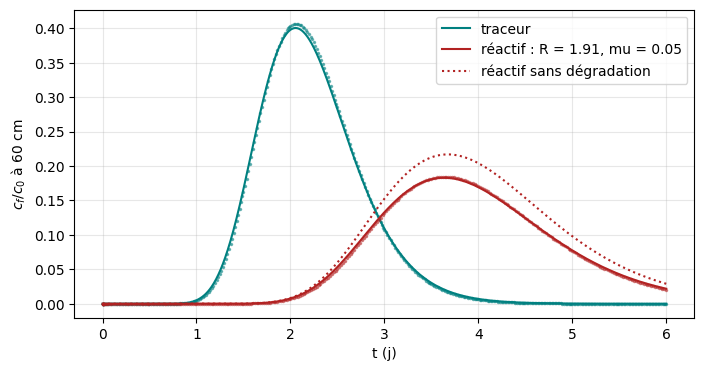

pic traceur 2.07 j, réactif 3.64 j (rapport 1.76)
temps moyen traceur 2.23 j, réactif 3.89 j ; R = (t_r - t0/2)/(t_t - t0/2) = 1.84 (théorie 1.91, BTC réactive tronquée à 6 j)
masse injectée 5.000 ; récupérée à 6 j : traceur 5.000, réactif 3.985
réactif : M exp(-mu t_moyen) = 4.088 ; intégrale analytique 0-inf = 4.145
BTC complète (0-6 j) : Kd = 0.2004 ± 0.0001, mu = 0.0497 ± 0.0002 /j, corrélation Kd-mu = -0.080
partie montante (t < 3,5 j) : Kd = 0.2033 ± 0.0000, mu = 0.0424 ± 0.0001 /j, corrélation Kd-mu = -0.897


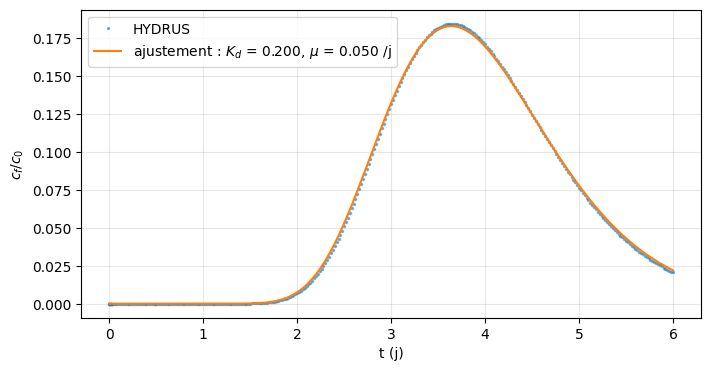

In [4]:
rho_b, Kd, mu = 1.5, 0.2, 0.05
R = 1 + rho_b * Kd / theta
D = 2.0 * v + De
so_t = read_solute(f"{HYD}/J10_traceur_disp2cm"); so_n = read_solute(f"{HYD}/J10_nitrate_reactif")
tt = np.linspace(1e-3, 6, 1500)
cf_t, tim_t = -so_t["cvBot"].to_numpy() / q, so_t.index.to_numpy()
cf_n, tim_n = -so_n["cvBot"].to_numpy() / q, so_n.index.to_numpy()

# 1. BTC
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tim_t, cf_t, ".", ms=3, color="teal", alpha=0.5); ax.plot(tt, ade_pulse(60, tt, v, D, t0), color="teal", label="traceur")
ax.plot(tim_n, cf_n, ".", ms=3, color="firebrick", alpha=0.5); ax.plot(tt, ade_pulse(60, tt, v, D, t0, R=R, mu=mu), color="firebrick", label=f"réactif : R = {R:.2f}, mu = {mu}")
ax.plot(tt, ade_pulse(60, tt, v, D, t0, R=R), ":", color="firebrick", label="réactif sans dégradation")
ax.set_xlabel("t (j)"); ax.set_ylabel("$c_f/c_0$ à 60 cm"); ax.legend(); plt.show()
def moments(cf, tim):
    M0 = np.trapezoid(cf, tim); return q * M0, np.trapezoid(tim * cf, tim) / M0
M_t, tb_t = moments(cf_t, tim_t); M_n, tb_n = moments(cf_n, tim_n)
print(f"pic traceur {tim_t[np.argmax(cf_t)]:.2f} j, réactif {tim_n[np.argmax(cf_n)]:.2f} j (rapport {tim_n[np.argmax(cf_n)]/tim_t[np.argmax(cf_t)]:.2f})")
print(f"temps moyen traceur {tb_t:.2f} j, réactif {tb_n:.2f} j ; R = (t_r - t0/2)/(t_t - t0/2) = {(tb_n - t0/2)/(tb_t - t0/2):.2f} (théorie {R:.2f}, BTC réactive tronquée à 6 j)")

# 2. masses
M_inf = integrate.quad(lambda t: q * ade_pulse(60, t, v, D, t0, R=R, mu=mu), 0, 40, limit=300)[0]
print(f"masse injectée {so_n['Sum(cvTop)'].iloc[-1]:.3f} ; récupérée à 6 j : traceur {-so_t['Sum(cvBot)'].iloc[-1]:.3f}, réactif {-so_n['Sum(cvBot)'].iloc[-1]:.3f}")
print(f"réactif : M exp(-mu t_moyen) = {5*np.exp(-mu*(R*L/v + t0/2)):.3f} ; intégrale analytique 0-inf = {M_inf:.3f}")

# 3. ajustement (Kd, mu)
def btc_reactif(t, Kd_, mu_):
    return ade_pulse(60, t, v, D, t0, R=1 + rho_b * Kd_ / theta, mu=mu_)
for lab, m in [("BTC complète (0-6 j)", tim_n > 0), ("partie montante (t < 3,5 j)", tim_n < 3.5)]:
    p, cov = optimize.curve_fit(btc_reactif, tim_n[m], cf_n[m], p0=[0.1, 0.02], bounds=([0, 0], [2, 1]))
    se = np.sqrt(np.diag(cov)); r = cov[0, 1] / (se[0] * se[1])
    print(f"{lab} : Kd = {p[0]:.4f} ± {se[0]:.4f}, mu = {p[1]:.4f} ± {se[1]:.4f} /j, corrélation Kd-mu = {r:.3f}")
p, cov = optimize.curve_fit(btc_reactif, tim_n, cf_n, p0=[0.1, 0.02], bounds=([0, 0], [2, 1]))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tim_n, cf_n, ".", ms=3, alpha=0.5, label="HYDRUS"); ax.plot(tt, btc_reactif(tt, *p), label=f"ajustement : $K_d$ = {p[0]:.3f}, $\\mu$ = {p[1]:.3f} /j")
ax.set_xlabel("t (j)"); ax.set_ylabel("$c_f/c_0$"); ax.legend(); plt.show()

**Commentaire (instructeur).** Le pic est retardé d'un facteur 1,76 et le centre de masse d'un facteur ≈ 1,9 = $R$ (la BTC réactive n'est pas terminée à 6 j, d'où
un $\bar t$ légèrement sous-estimé). 17 % de la masse est dégradée ($e^{-\mu\bar t}$ = 0,82) : HYDRUS restitue 3,98 à 6 j et la solution
analytique 4,15 à l'infini. L'ajustement sur la BTC complète retrouve $K_d$ = 0,20 et $\mu$ = 0,05 avec des écarts-types de quelques pour cent
et une corrélation quasi nulle ; sur la seule partie montante, $\mu$ est biaisé (0,042) et les deux paramètres deviennent fortement corrélés
($r = -0{,}9$ : un retard plus grand et une dégradation plus faible produisent la même montée) : il faut la descente et la masse totale pour les séparer.

## Exercice 4 — Modélisation inverse : estimer ($\alpha$, $n$, $K_s$) avec un solveur de Richards  *(≈ 20 min)*

`data/J10_inverse_donnees.csv` : infiltration cumulée $I(t)$ ($\sigma_I$ = 0,2 cm) et charges de pression à 10, 30 et 50 cm ($\sigma_h$ = 3 cm),
toutes les 0,05 j pendant 1 j, pour une infiltration submergée ($h_{top} = 0$) dans un loam à $h_0 = -100$ cm (données de
`J06_infiltration_submergee_loam` bruitées). $\theta_r = 0{,}078$ et $\theta_s = 0{,}43$ sont connus.

Le solveur `richards_1d(par, t_out=...)` (forme mixte, Picard modifié, tridiagonal, MvG, drainage libre) est fourni : il renvoie $I$ et $h$ aux
mêmes instants (≈ 0,5 s par appel).

1. Vérifier le solveur avec les vrais paramètres (0,036 ; 1,56 ; 24,96) : RMSE par rapport aux données.
2. Écrire la fonction résidu pondéré $r_i = (y_i^{obs} - y_i(\mathbf b))/\sigma_i$ pour $\mathbf b = \log(\alpha, n, K_s)$ et lancer
   `scipy.optimize.least_squares` (bornes : $\alpha \in [0{,}005 ; 0{,}2]$, $n \in [1{,}15 ; 3]$, $K_s \in [2 ; 500]$ ; `diff_step=0.02`,
   `xtol=ftol=1e-4`) depuis (0,02 ; 1,8 ; 50). Temps de calcul, nombre d'évaluations, paramètres estimés.
3. Covariance $\mathbf C = s^2(\mathbf J^T\mathbf J)^{-1}$ avec $s^2 = 2\Phi_{min}/(N - p)$ (`res.jac`, `res.cost`) ; écarts-types, IC 95 %
   (en log puis relatifs), matrice de corrélation ; tracer les résidus.
4. Refaire l'estimation avec $I(t)$ seule : que deviennent les incertitudes et les corrélations ? Conclure sur l'identifiabilité.
5. Décrire la marche à suivre équivalente dans HYDRUS-1D (Main Processes → Inverse Solution ; types de données 0 et 1).

un appel : 0.61 s ; RMSE I = 0.228 cm (sigma 0,2) ; RMSE h = 2.94 cm (sigma 3)


least_squares : 16 s, 14 évaluations, statut 3 ; Phi_min = 74.5 pour N = 80
estimé : alpha = 0.0363 (vrai 0,036), n = 1.547 (1,56), Ks = 25.21 cm/j (24,96)


,estimé,vrai,IC95 relatif (%)
alpha,0.036,0.036,5.069
n,1.547,1.560,1.678
Ks,25.211,24.960,0.860


corrélation :


,alpha,n,Ks
alpha,1.00,-0.62,0.72
n,-0.62,1.00,-0.72
Ks,0.72,-0.72,1.00


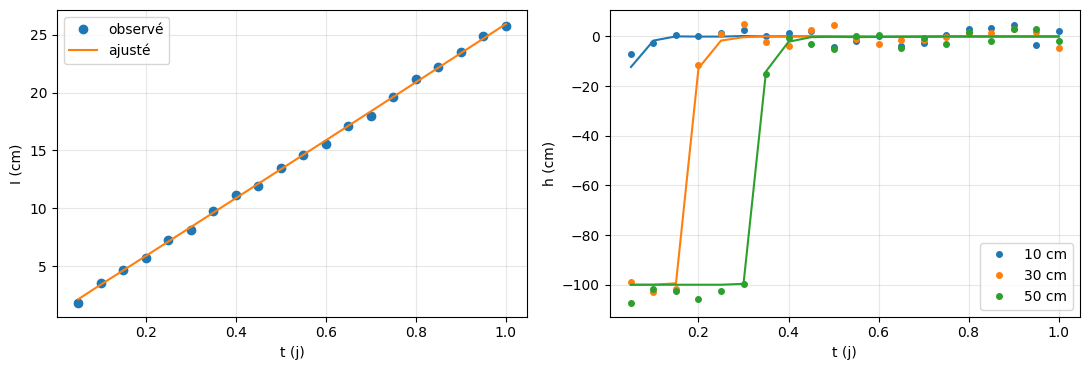

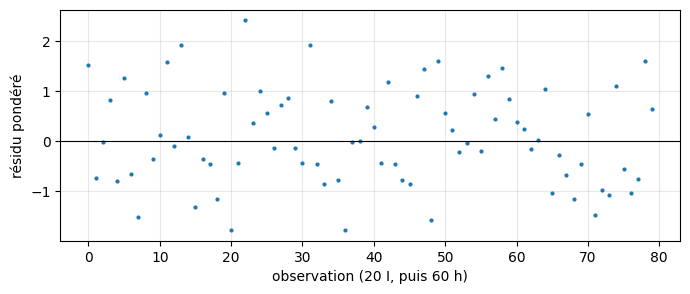

I(t) seule : 22 s, 13 évaluations ; estimé alpha = 0.0454, n = 1.554, Ks = 25.31
IC95 relatif (%) : [4.653e+03 3.920e+01 1.500e+00]
corrélation :


,alpha,n,Ks
alpha,1.00,0.99,0.44
n,0.99,1.00,0.30
Ks,0.44,0.30,1.00


In [5]:
def richards_1d(par, L=100.0, dz=1.0, h_init=-100.0, h_top=0.0, t_out=None, z_obs=(10, 30, 50),
                dt0=1e-4, dt_max=0.02, tol_th=2e-4, tol_h=1.0, max_iter=12):
    """Richards 1D en forme mixte (Celia et al. 1990), itération de Picard modifiée, système tridiagonal, Mualem-van Genuchten.
    z positif vers le haut (0 = surface). Haut : charge imposée h_top (submersion) ; bas : drainage libre (gradient unitaire).
    par = (thr, ths, alpha, n, Ks) en cm et jours. Retourne t_out, I(t_out) (infiltration cumulée, cm) et h(t_out, z_obs)."""
    thr, ths, a, n, Ks = par; m = 1 - 1 / n
    Se_f = lambda h: np.where(h < 0, (1 + (a * np.abs(h)) ** n) ** (-m), 1.0)
    theta = lambda h: thr + (ths - thr) * Se_f(h)
    K = lambda h: Ks * Se_f(h) ** 0.5 * (1 - (1 - Se_f(h) ** (1 / m)) ** m) ** 2
    C = lambda h: np.where(h < 0, (ths - thr) * a * n * m * (a * np.abs(h)) ** (n - 1) * Se_f(h) ** (1 + 1 / m), 0.0)
    N = int(round(L / dz)) + 1
    h = np.full(N, h_init, float); h[0] = h_top
    iobs = [int(round(zo / dz)) for zo in z_obs]
    t_out = np.asarray(t_out, float)
    t, dt, I, k_out = 0.0, dt0, 0.0, 0
    I_out, h_out = [], []
    while k_out < len(t_out):
        dt = min(dt, t_out[k_out] - t)
        th_old = theta(h); hk = h.copy()
        for it in range(max_iter):                                   # itérations de Picard
            Kn = K(hk); Km = 0.5 * (Kn[:-1] + Kn[1:]); thk = theta(hk)   # K inter-nodale (moyenne arithmétique)
            q = Km * ((hk[:-1] - hk[1:]) / dz + 1)                     # flux vers le bas entre les noeuds i et i+1
            rhs = np.empty(N); rhs[0] = 0.0                            # résidu : -(theta^k - theta^n)/dt + div(q)
            rhs[1:-1] = -(thk[1:-1] - th_old[1:-1]) / dt + (q[:-1] - q[1:]) / dz
            rhs[-1] = -(thk[-1] - th_old[-1]) / dt + (q[-1] - Kn[-1]) / dz     # drainage libre : q_bas = K(h_N)
            main = C(hk) / dt; main[1:-1] += (Km[:-1] + Km[1:]) / dz ** 2; main[-1] += Km[-1] / dz ** 2; main[0] = 1.0
            ab = np.zeros((3, N)); ab[1] = main; ab[0, 2:] = -Km[1:] / dz ** 2; ab[2, :-1] = -Km / dz ** 2; ab[2, 0] = 0.0
            dh = linalg.solve_banded((1, 1), ab, rhs); hk = hk + dh
            dth = np.abs(theta(hk) - thk); sat = hk >= 0                # critères de HYDRUS : theta (non saturé), h (saturé)
            if np.max(np.where(sat, 0.0, dth)) < tol_th and np.max(np.where(sat, np.abs(dh), 0.0)) < tol_h: break
        else:
            dt *= 0.3; continue                                       # non-convergence : on recommence avec un pas réduit
        Kn = K(hk)                                                    # flux en surface = flux 0-1 + stockage du demi-noeud 0
        I += (0.5 * (Kn[0] + Kn[1]) * ((hk[0] - hk[1]) / dz + 1) + (theta(hk)[0] - th_old[0]) * dz / (2 * dt)) * dt
        t += dt; h = hk
        if abs(t - t_out[k_out]) < 1e-10:
            I_out.append(I); h_out.append(h[iobs].copy()); k_out += 1
        dt = min(dt * (1.3 if it <= 3 else 0.5 if it >= 7 else 1.0), dt_max)   # contrôle du pas par le nombre d'itérations
    return t_out, np.array(I_out), np.array(h_out)


don = pd.read_csv("data/J10_inverse_donnees.csv")
t_obs = don["t_j"].to_numpy(); I_obs = don["I_cm"].to_numpy(); H_obs = don[["h10_cm", "h30_cm", "h50_cm"]].to_numpy()
sI, sH = 0.2, 3.0
THR, THS = 0.078, 0.43

# 1. vérification
t_c = time.time(); _, I_m, H_m = richards_1d([THR, THS, 0.036, 1.56, 24.96], t_out=t_obs); dt_run = time.time() - t_c
print(f"un appel : {dt_run:.2f} s ; RMSE I = {np.sqrt(np.mean((I_m - I_obs)**2)):.3f} cm (sigma 0,2) ; RMSE h = {np.sqrt(np.mean((H_m - H_obs)**2)):.2f} cm (sigma 3)")

# 2. estimation
def residu(p, with_h=True):
    a, n, Ks = np.exp(p)
    _, Im, Hm = richards_1d([THR, THS, a, n, Ks], t_out=t_obs)
    r = [(Im - I_obs) / sI]
    if with_h:
        r.append(((Hm - H_obs) / sH).ravel())
    return np.concatenate(r)

bornes = (np.log([0.005, 1.15, 2.0]), np.log([0.2, 3.0, 500.0]))
t_c = time.time()
res = optimize.least_squares(residu, np.log([0.02, 1.8, 50.0]), bounds=bornes, diff_step=0.02, xtol=1e-4, ftol=1e-4)
print(f"least_squares : {time.time()-t_c:.0f} s, {res.nfev} évaluations, statut {res.status} ; Phi_min = {2*res.cost:.1f} pour N = {res.fun.size}")
est = np.exp(res.x)
print(f"estimé : alpha = {est[0]:.4f} (vrai 0,036), n = {est[1]:.3f} (1,56), Ks = {est[2]:.2f} cm/j (24,96)")

# 3. incertitudes
def incertitudes(res, p=3):
    J = res.jac; s2 = 2 * res.cost / (res.fun.size - p)
    cov = s2 * np.linalg.inv(J.T @ J); se = np.sqrt(np.diag(cov))
    return se, cov / np.outer(se, se)
se, corr = incertitudes(res)
tab = pd.DataFrame({"estimé": est, "vrai": [0.036, 1.56, 24.96], "IC95 relatif (%)": 100 * (np.exp(1.96 * se) - 1)}, index=["alpha", "n", "Ks"])
display(tab.round(3)); print("corrélation :"); display(pd.DataFrame(corr, index=tab.index, columns=tab.index).round(2))
_, I_f, H_f = richards_1d([THR, THS, *est], t_out=t_obs)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(t_obs, I_obs, "o", label="observé"); ax[0].plot(t_obs, I_f, "-", label="ajusté"); ax[0].set_xlabel("t (j)"); ax[0].set_ylabel("I (cm)"); ax[0].legend()
for k, z in enumerate([10, 30, 50]):
    ax[1].plot(t_obs, H_obs[:, k], "o", ms=4, color=f"C{k}", label=f"{z} cm"); ax[1].plot(t_obs, H_f[:, k], "-", color=f"C{k}")
ax[1].set_xlabel("t (j)"); ax[1].set_ylabel("h (cm)"); ax[1].legend(); plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(res.fun, ".", ms=4); ax.axhline(0, color="k", lw=0.8); ax.set_ylabel("résidu pondéré"); ax.set_xlabel("observation (20 I, puis 60 h)"); plt.show()

# 4. infiltration seule
t_c = time.time()
res_I = optimize.least_squares(lambda p: residu(p, with_h=False), np.log([0.02, 1.8, 50.0]), bounds=bornes, diff_step=0.02, xtol=1e-4, ftol=1e-4)
se_I, corr_I = incertitudes(res_I)
print(f"I(t) seule : {time.time()-t_c:.0f} s, {res_I.nfev} évaluations ; estimé alpha = {np.exp(res_I.x[0]):.4f}, n = {np.exp(res_I.x[1]):.3f}, Ks = {np.exp(res_I.x[2]):.2f}")
print("IC95 relatif (%) :", np.round(100 * (np.exp(1.96 * se_I) - 1), 1)); print("corrélation :"); display(pd.DataFrame(corr_I, index=tab.index, columns=tab.index).round(2))

**Commentaire (instructeur).** Avec infiltration + tensiomètres, les trois paramètres sont retrouvés à 1–2 % près en 14 évaluations (≈ 16 s) :
IC à 95 % de ± 5 % sur $\alpha$, ± 1,7 % sur $n$ et ± 0,9 % sur $K_s$, corrélations de 0,6–0,7 (identifiabilité correcte). Avec $I(t)$ seule,
$K_s$ reste bien contraint (pente finale de $I$) mais $\alpha$ part à 0,045 avec un IC de plusieurs ordres de grandeur et une corrélation
$\alpha$–$n$ de 0,99 : une infinité de couples ($\alpha$, $n$) donnent la même sorptivité. Dans HYDRUS-1D : Main Processes → *Inverse Solution* ;
cocher *Fitted* pour $\alpha$, $n$, $K_s$ avec bornes ; *Data for Inverse Solution* : type 0 (infiltration cumulée, position 0) et type 1
($h$ aux nœuds d'observation 1, 2, 3) avec poids $1/\sigma$ ; 15 itérations ; lire FIT.OUT (paramètres, écarts-types, corrélations).

## Exercice 5 — Bonus — surface de réponse et identifiabilité  *(≈ facultatif)*

Calculer $\Phi(\alpha, n)$ ($K_s$ = 24,96 fixé) sur une grille 6 × 6 ($\alpha \in [0{,}015 ; 0{,}07]$, $n \in [1{,}25 ; 2{,}1]$) avec et sans les
données de $h$ ; tracer $\log_{10}\Phi$ en isolignes et situer les vraies valeurs. Commenter la forme des vallées.

36 simulations en 53 s


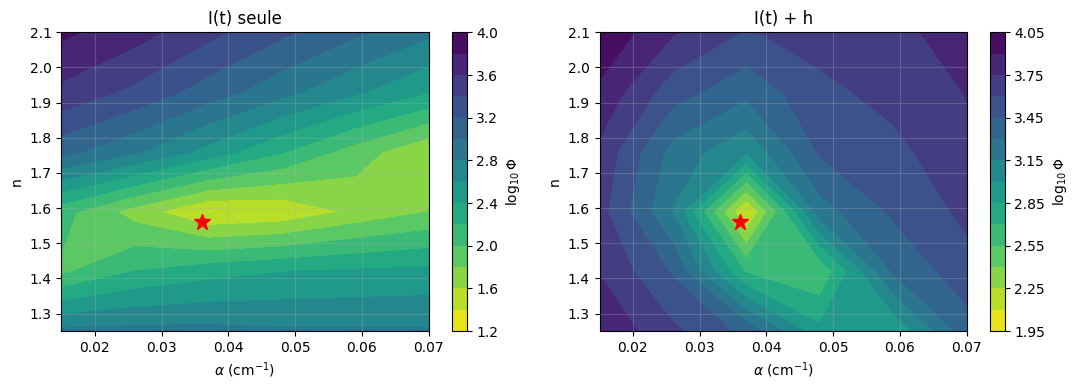

In [6]:
al = np.linspace(0.015, 0.07, 6); nn = np.linspace(1.25, 2.1, 6)
t_c = time.time()
PHI = np.zeros((6, 6)); PHI_I = np.zeros((6, 6))
for i, n_ in enumerate(nn):
    for j, a_ in enumerate(al):
        r = residu(np.log([a_, n_, 24.96]))
        PHI[i, j] = np.sum(r ** 2); PHI_I[i, j] = np.sum(r[:20] ** 2)
print(f"{6*6} simulations en {time.time()-t_c:.0f} s")
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, Z, ttl in [(ax[0], PHI_I, "I(t) seule"), (ax[1], PHI, "I(t) + h")]:
    cs = a.contourf(al, nn, np.log10(Z), levels=15, cmap="viridis_r"); plt.colorbar(cs, ax=a, label="$\\log_{10}\\Phi$")
    a.plot(0.036, 1.56, "r*", ms=12); a.set_xlabel(r"$\alpha$ (cm$^{-1}$)"); a.set_ylabel("n"); a.set_title(ttl)
plt.tight_layout(); plt.show()

**Commentaire (instructeur).** Avec $I(t)$ seule, la surface présente une vallée allongée : $\Phi$ varie peu le long d'une courbe $\alpha$–$n$ (même sorptivité).
Avec les charges de pression, le minimum devient un puits bien fermé autour de (0,036 ; 1,56). C'est l'image géométrique de la corrélation
entre paramètres ; l'IC linéarisé de l'exercice 4 n'est fiable que si la vallée est à peu près elliptique près du minimum.

## Pour aller plus loin

* Ajouter $\theta_s$ aux paramètres ajustés : identifiable avec ces données ? Et $\theta_r$ ?
* Remplacer les données de $h$ par des teneurs en eau $\theta$ (sondes) : comparer les incertitudes.
* Estimer ($\lambda$, $R$, $\mu$) sur les BTC HYDRUS par `least_squares` autour d'un schéma numérique de l'ADE (Crank–Nicolson), puis avec
  un modèle mobile–immobile ($\theta_{im}$, $\alpha$) : quelles données permettent de distinguer les deux modèles ?
* Refaire l'exercice 4 dans HYDRUS-1D (Inverse Solution) et comparer FIT.OUT aux résultats Python.